# Baseline results - species grouped by growth form and special status 

## Python library imports

In [9]:
import matplotlib.pyplot as pyplt
import matplotlib.ticker
import pandas as pd
import Common

## Read FLTS dataset results

In [10]:
dataset = pd.read_csv('../floralens/flts_floralens.tsv', sep='\t')
#dataset

## Auxilliary function to compute statistics

In [11]:
def get_stats_for_species_list(label, species_list, dataset):
    species = pd.DataFrame(species_list,columns=['species'])
    subset = species.merge(dataset,on=['species'])
    return [
        label,
        len(species),
        len(subset),
        Common.top1(subset),
        Common.top5(subset),
        Common.mrr(subset)
    ]

## Matplotlib configuration

In [12]:
font = {'family' : 'normal',
        'size'   : 12}
pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (9,6)

## Growth form results

In [13]:
growth_forms = ['fern', 'grass', 'herb', 'shrub', 'tree']
plot_data = pd.DataFrame([
    get_stats_for_species_list(gf, Common.read_lines_in_file('../flora-on/categories/gf_' + gf + '_species.txt'), dataset) \
    for gf in growth_forms
], columns=['Category','# Species', '# Images', 'Top-1', 'Top-5', 'MRR'])  
plot_data

,Category,# Species,# Images,Top-1,Top-5,MRR
0,fern,42,771,0.680934,0.894942,0.764591
1,grass,113,2021,0.499753,0.748144,0.593295
2,herb,1401,24410,0.668128,0.860139,0.744480
3,shrub,225,3983,0.691941,0.877228,0.766047
4,tree,80,1529,0.612165,0.839111,0.701439


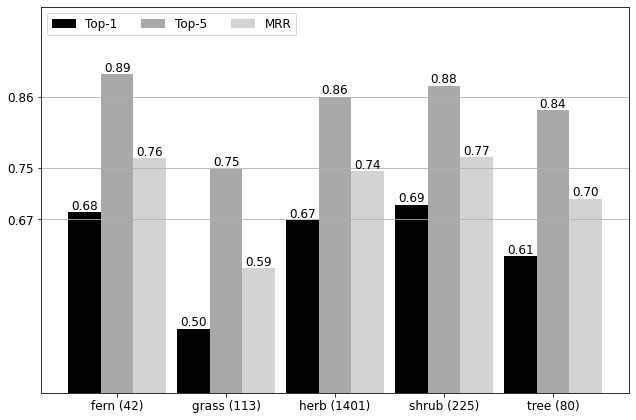

In [14]:
plt = plot_data.plot.bar(x='Category',y=['Top-1','Top-5', 'MRR'],color=['black','darkgray','lightgray'],width=0.9)
plt.legend(loc='upper left',ncol=3)
plt.set_ylim([0.40,1.0])
plt.set_xlabel('')
plt.set_yticks([0.67,0.75,0.86])
plt.grid(axis='y')
plot_data.set_index('Category',inplace=True)
x_labels = ["{} ({})".format(gf,plot_data['# Species'][gf]) for gf in growth_forms]
plt.set_xticklabels(x_labels, rotation=0, ha='center')
#plt.invert_yaxis()
for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/growth_form_results.pdf') 

## Special status results

In [15]:
status_labels = ['endangered', 'endemic', 'protected', 'rare']
plot_data = pd.DataFrame([
    get_stats_for_species_list(sl, 
                               Common.read_lines_in_file('../flora-on/categories/cs_' + sl + '_species.txt'), 
                               dataset) \
    for sl in status_labels
], columns=['Category','# Species', '# Images', 'Top-1', 'Top-5', 'MRR'])  
plot_data

,Category,# Species,# Images,Top-1,Top-5,MRR
0,endangered,152,2452,0.709217,0.887031,0.778541
1,endemic,28,397,0.662469,0.871537,0.740260
2,protected,31,433,0.685912,0.893764,0.765473
3,rare,229,3902,0.657099,0.856740,0.734751


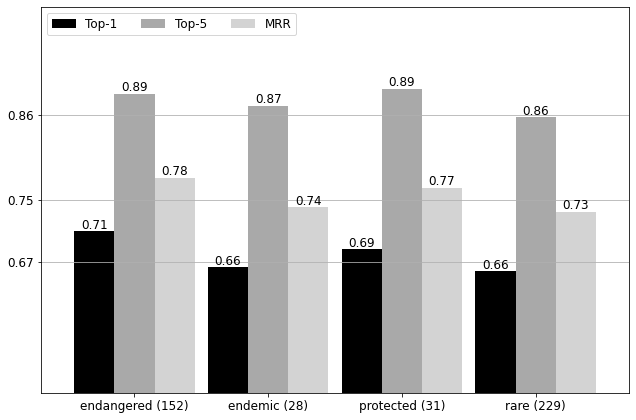

In [16]:
plt = plot_data.plot.bar(x='Category',y=['Top-1','Top-5', 'MRR'],color=['black','darkgray','lightgray'],width=0.9)
plt.legend(loc='upper left',ncol=3)
plt.set_ylim([0.50,1.0])
plt.set_xlabel('')
plt.set_yticks([0.67,0.75,0.86])
plt.grid(axis='y')
plot_data.set_index('Category',inplace=True)
x_labels = ["{} ({})".format(sl, plot_data['# Species'][sl]) for sl in status_labels]
plt.set_xticklabels(x_labels, rotation=0, ha='center')
#plt.invert_yaxis()
for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/special_status_results.pdf') 